In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
csv_filename = "../CleanData/master_set_without_imputation_4_27_25.csv"
df = pd.read_csv(csv_filename)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91210 entries, 0 to 91209
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            91210 non-null  int64  
 1   gid                   91210 non-null  object 
 2   visteam               91210 non-null  object 
 3   hometeam              91210 non-null  object 
 4   site                  91210 non-null  object 
 5   number                91210 non-null  float64
 6   daynight              91210 non-null  int64  
 7   attendance            91210 non-null  int64  
 8   temp                  91210 non-null  float64
 9   windspeed             91210 non-null  float64
 10  season                91210 non-null  int64  
 11  vruns                 91210 non-null  int64  
 12  hruns                 91210 non-null  int64  
 13  wteam                 91210 non-null  object 
 14  lteam                 91210 non-null  object 
 15  team               

In [52]:
# convert some column types into int
df = df.drop(columns=['Unnamed: 0', 'number'])  # remove redundant columns
for col in ['left_on_base', 'bat_doubles', 'bat_triples', 'bat_home_runs', 'bat_stolen_bases', 'passed_balls_allowed', 'errors_committed', 'stolen_bases', 'salary', 'score_diff']:
    df[col] = df[col].astype(int)

for col in ['gid', 'visteam', 'hometeam', 'site', 'wteam', 'lteam', 'team', 'teamID']:
    df[col] = df[col].astype('category')

df['date'] = pd.to_datetime(df['date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91210 entries, 0 to 91209
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   gid                   91210 non-null  category      
 1   visteam               91210 non-null  category      
 2   hometeam              91210 non-null  category      
 3   site                  91210 non-null  category      
 4   daynight              91210 non-null  int64         
 5   attendance            91210 non-null  int64         
 6   temp                  91210 non-null  float64       
 7   windspeed             91210 non-null  float64       
 8   season                91210 non-null  int64         
 9   vruns                 91210 non-null  int64         
 10  hruns                 91210 non-null  int64         
 11  wteam                 91210 non-null  category      
 12  lteam                 91210 non-null  category      
 13  team            

In [53]:
# check nulls
df.isna().sum()

gid                     0
visteam                 0
hometeam                0
site                    0
daynight                0
attendance              0
temp                    0
windspeed               0
season                  0
vruns                   0
hruns                   0
wteam                   0
lteam                   0
team                    0
Home_Away               0
score_diff              0
left_on_base            0
bat_doubles             0
bat_triples             0
bat_home_runs           0
bat_stolen_bases        0
passed_balls_allowed    0
errors_committed        0
stolen_bases            0
date                    0
yearID                  0
teamID                  0
salary                  0
dtype: int64

In [54]:
# summary stats
df.describe(include='all')

,gid,visteam,hometeam,site,daynight,attendance,temp,windspeed,season,vruns,...,bat_triples,bat_home_runs,bat_stolen_bases,passed_balls_allowed,errors_committed,stolen_bases,date,yearID,teamID,salary
count,91210,91210,91210,91210,91210.000000,91210.00000,91210.000000,91210.000000,91210.000000,91210.00000,...,91210.000000,91210.000000,91210.000000,91210.000000,91210.000000,91210.000000,91210,91210.000000,91210,9.121000e+04
unique,91209,33,33,72,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33,NaN
top,ATL198605200,SEA,SFN,ANA01,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SDN,NaN
freq,2,3161,3164,3163,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3252,NaN
mean,NaN,NaN,NaN,NaN,0.330687,28175.24846,65.275507,6.580868,2004.883072,4.49954,...,0.186756,1.030764,0.631674,0.071483,0.657307,0.635292,2005-05-22 03:12:41.363885696,2004.883072,NaN,6.587325e+07
min,NaN,NaN,NaN,NaN,0.000000,0.00000,0.000000,-1.000000,1985.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1985-04-08 00:00:00,1985.000000,NaN,8.800000e+05
25%,NaN,NaN,NaN,NaN,0.000000,18974.00000,63.000000,0.000000,1996.000000,2.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1996-04-11 00:00:00,1996.000000,NaN,3.021050e+07
50%,NaN,NaN,NaN,NaN,0.000000,28260.00000,72.000000,7.000000,2005.000000,4.00000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2005-07-20 00:00:00,2005.000000,NaN,5.680246e+07
75%,NaN,NaN,NaN,NaN,1.000000,37680.00000,79.000000,10.000000,2014.000000,6.00000,...,0.000000,2.000000,1.000000,0.000000,1.000000,1.000000,2014-09-23 00:00:00,2014.000000,NaN,9.053685e+07
max,NaN,NaN,NaN,NaN,1.000000,80227.00000,113.000000,40.000000,2024.000000,30.00000,...,5.000000,10.000000,10.000000,5.000000,7.000000,10.000000,2024-09-30 00:00:00,2024.000000,NaN,2.603986e+08


In [55]:
# check if `gid` is unique
df['gid'].is_unique

False

In [56]:
# Find all duplicated gid values (keeping all instances, not just the second)
duplicates = df[df.duplicated('gid', keep=False)]
duplicates = duplicates.sort_values('gid')
duplicates.head()

,gid,visteam,hometeam,site,daynight,attendance,temp,windspeed,season,vruns,...,bat_triples,bat_home_runs,bat_stolen_bases,passed_balls_allowed,errors_committed,stolen_bases,date,yearID,teamID,salary
2561,ATL198605200,CHN,ATL,ATL01,0,16925,0.0,-1.0,1986,3,...,0,1,1,0,3,0,1986-05-20,1986,CHN,17208165
2562,ATL198605200,CHN,ATL,ATL01,0,16925,0.0,-1.0,1986,3,...,0,1,1,0,3,0,1986-05-20,1986,CHN,17208165


There are 2 records identical: need to remove dupes

In [57]:
# remove duplicates based on `gid`
df = df.drop_duplicates(subset='gid', keep='first')

In [58]:
# Check if 'teamID' and 'team' are equal for all rows
team_match = (df['teamID'] == df['team']).all()
print(f"'teamID' == 'team' for all rows? {team_match}")

'teamID' == 'team' for all rows? True


teamID and team columns are identical: we can keep only one

In [59]:
# Check if 'season' and 'yearID' are equal for all rows
season_match = (df['season'] == df['yearID']).all()
print(f"'season' == 'yearID' for all rows? {season_match}")

'season' == 'yearID' for all rows? True


season and yearID columns are identical: we can keep only one

In [60]:
df = df.drop(columns=['team', 'season'])
df.head()

,gid,visteam,hometeam,site,daynight,attendance,temp,windspeed,vruns,hruns,...,bat_triples,bat_home_runs,bat_stolen_bases,passed_balls_allowed,errors_committed,stolen_bases,date,yearID,teamID,salary
0,BAL198504080,TEX,BAL,BAL11,1,50402,0.0,-1.0,2,4,...,0,0,0,1,0,0,1985-04-08,1985,TEX,7676500
1,BOS198504080,NYA,BOS,BOS07,1,34282,0.0,-1.0,2,9,...,0,0,0,0,0,1,1985-04-08,1985,NYA,14238204
2,CIN198504080,MON,CIN,CIN08,1,52971,0.0,-1.0,1,4,...,0,0,3,0,0,0,1985-04-08,1985,CIN,8359917
3,DET198504080,CLE,DET,DET04,1,51180,42.0,13.0,4,5,...,0,0,1,0,0,1,1985-04-08,1985,DET,10348143
4,KCA198504080,TOR,KCA,KAN06,1,41086,0.0,-1.0,1,2,...,0,0,1,0,1,0,1985-04-08,1985,TOR,8812550


In [61]:
invalid_winners = set((df['wteam'] == df['teamID']) & (df['score_diff'] < 0))
print(f"Invalid winners (where score is positive but team has lost)? {len(invalid_winners) > 1}")

Invalid winners (where score is positive but team has lost)? False


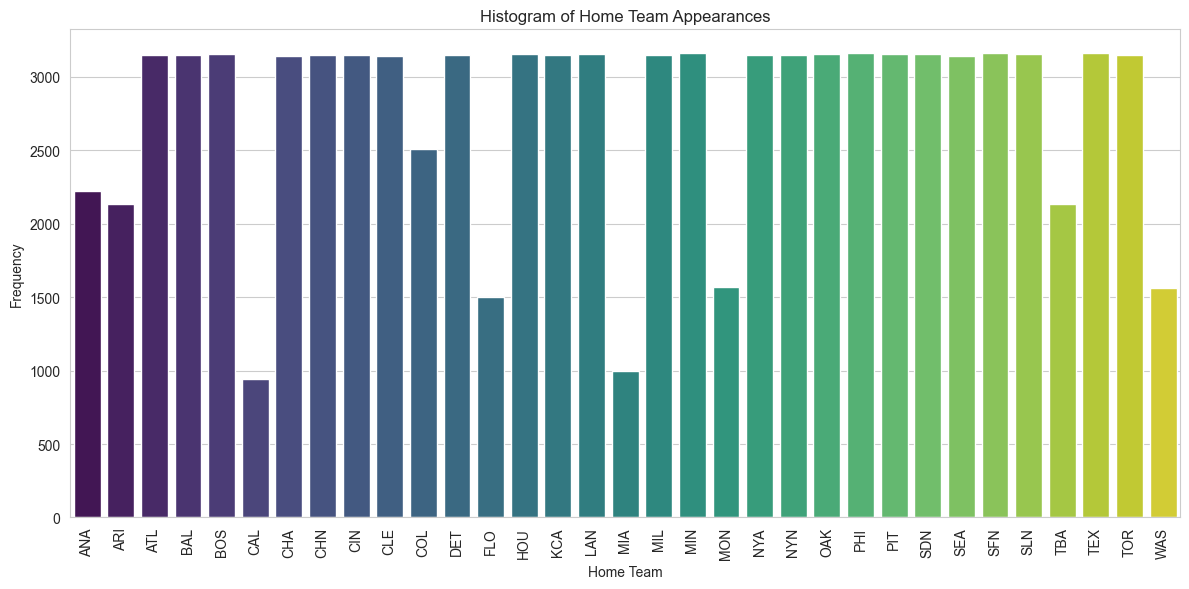

In [62]:
# Count frequencies of each home team
home_counts = df['hometeam'].value_counts()
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(x=home_counts.index, y=home_counts.values, palette="viridis", hue=home_counts.index, legend=False)

plt.xticks(rotation=90)
plt.title("Histogram of Home Team Appearances")
plt.xlabel("Home Team")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

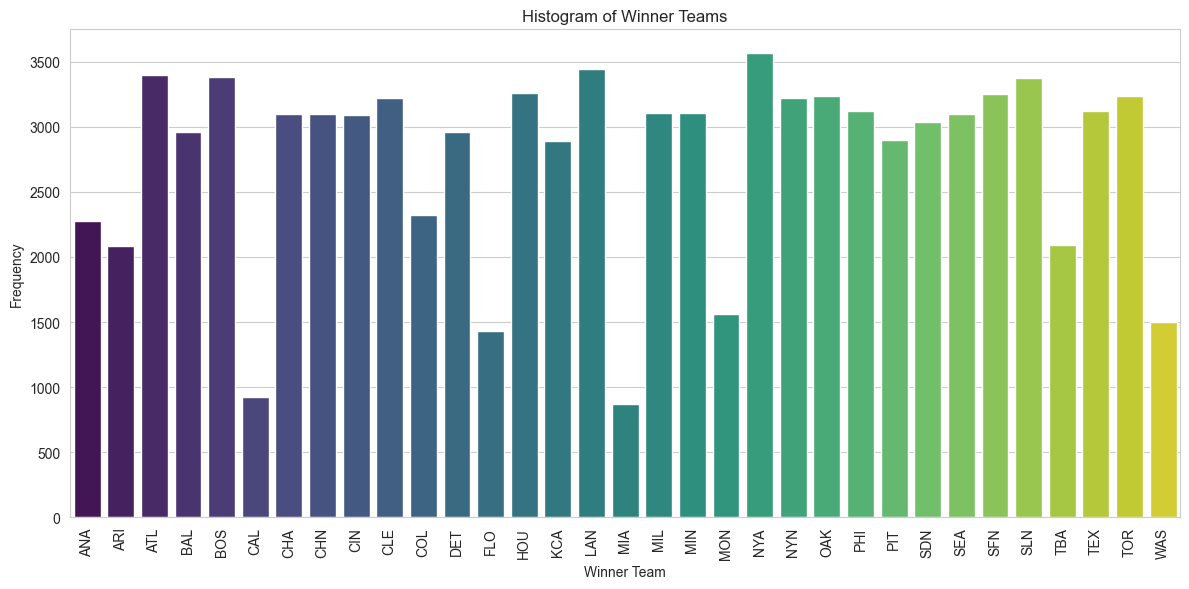

In [63]:
# Count frequencies of each winner team
winner_counts = df['wteam'].value_counts()
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(x=winner_counts.index, y=winner_counts.values, palette="viridis", hue=winner_counts.index, legend=False)

plt.xticks(rotation=90)
plt.title("Histogram of Winner Teams")
plt.xlabel("Winner Team")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

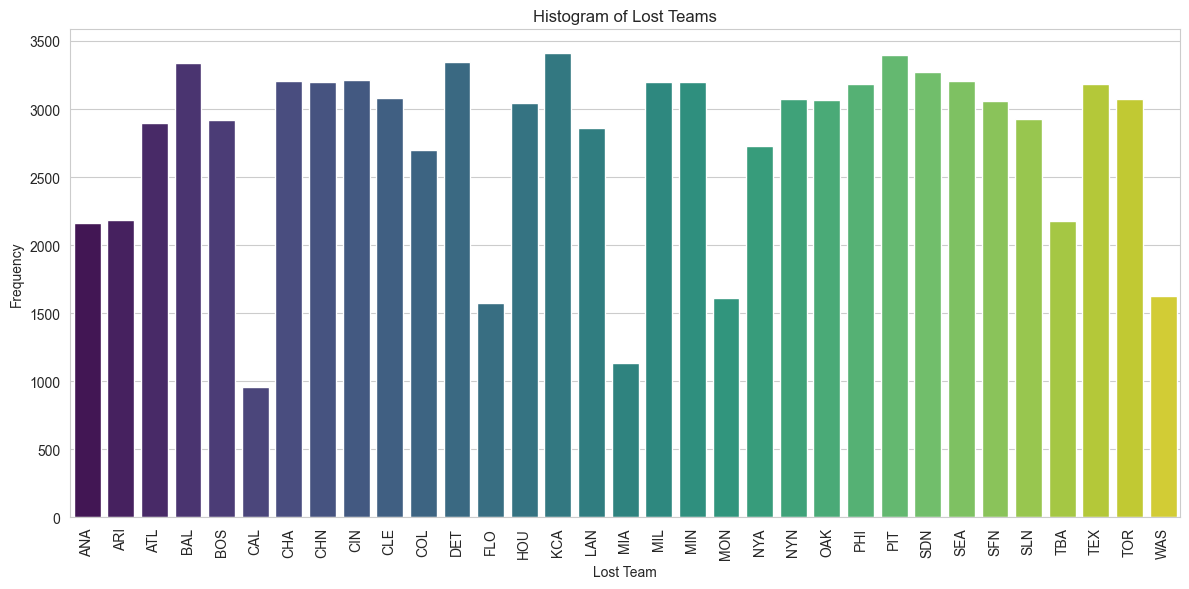

In [64]:
# Count frequencies of each winner team
lost_counts = df['lteam'].value_counts()
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(x=lost_counts.index, y=lost_counts.values, palette="viridis", hue=lost_counts.index, legend=False)

plt.xticks(rotation=90)
plt.title("Histogram of Lost Teams")
plt.xlabel("Lost Team")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Weather analysis

In [65]:
# average and min/max temp and windspeed
summary = df[['temp', 'windspeed']].agg(['mean', 'std', 'min', 'max']).round(2)
print(summary)

        temp  windspeed
mean   65.28       6.58
std    24.92       5.85
min     0.00      -1.00
max   113.00      40.00


Correlation

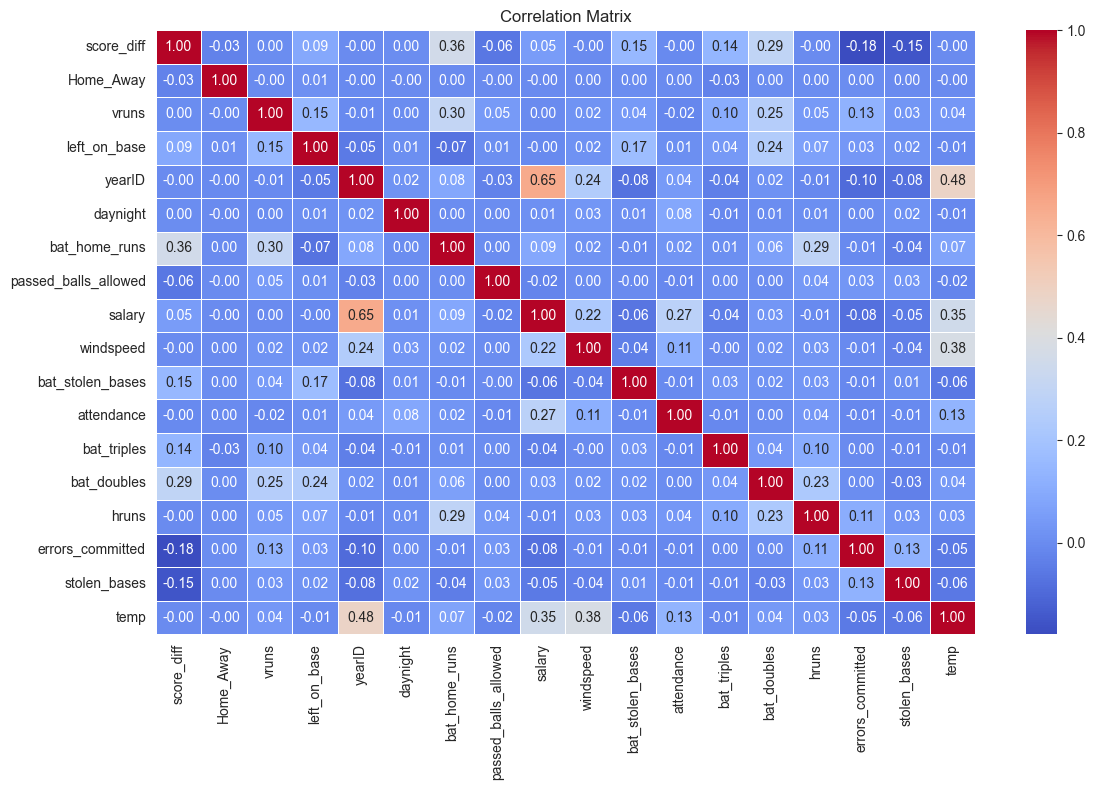

In [66]:
correlation_matrix = df.corr(numeric_only=True)

# Move 'score_diff' to the diagonal position
cols = set(correlation_matrix.columns)
cols = ['score_diff'] + list(cols.difference(['score_diff']))
correlation_matrix = correlation_matrix[cols].loc[cols]

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

`bat_home_runs` seems like to have highest correlation. But this will be unknown before game, so we cannot use it.
Does the day or night actually has any impact on score?

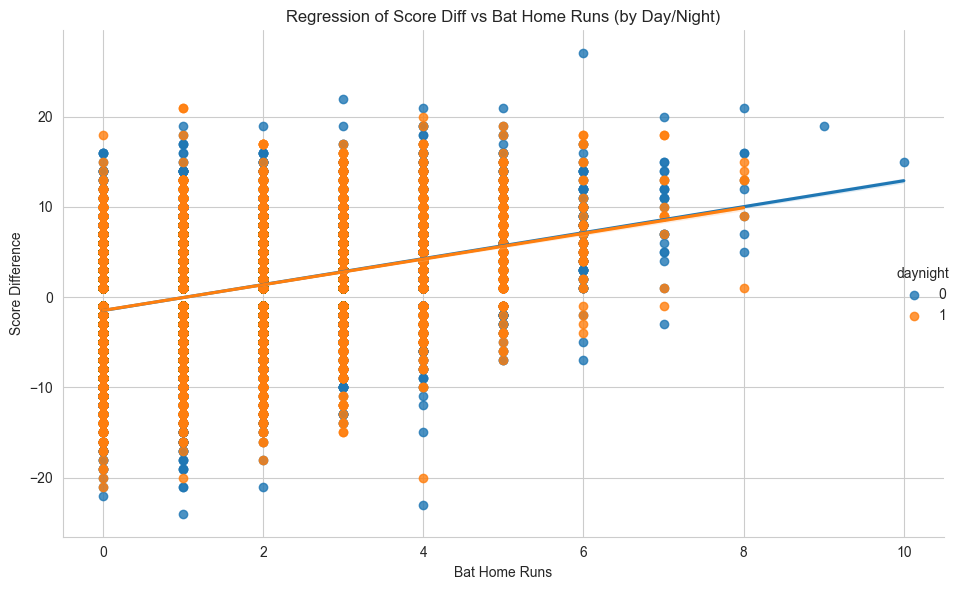

In [67]:
sns.set_style("whitegrid")

# Regression plot
sns.lmplot(
    data=df,
    x='bat_home_runs',
    y='score_diff',
    hue='daynight',
    height=6,
    aspect=1.5
)

plt.title("Regression of Score Diff vs Bat Home Runs (by Day/Night)")
plt.xlabel("Bat Home Runs")
plt.ylabel("Score Difference")
plt.tight_layout()
plt.show()

# no difference

Save full clean dataframe

In [68]:
df.to_csv("../CleanData/full_clean_data_without_imput.csv", index=False)